IMPORT LIBRARY

In [37]:
# Install Library yang dibutuhkan
#%pip install TA-Lib
#%pip install bayesian-optimization

In [38]:
# Library
import pandas as pd
import numpy as np
from warnings import filterwarnings
filterwarnings('ignore')

# Grafik dan Visualisasi
import matplotlib.pyplot as plt
import seaborn as sns 

# Indikator Teknikal Saham
import talib

# Machine Learning
from sklearn.ensemble import RandomForestRegressor
from sklearn.tree import plot_tree
from bayes_opt import BayesianOptimization
from sklearn.model_selection import TimeSeriesSplit, cross_val_score
from sklearn.metrics import mean_absolute_error, mean_absolute_percentage_error, root_mean_squared_error, r2_score

plt.rcParams['font.size'] = 14

I. DATA COLLECTION

In [39]:
# Memasukkan Data Olahan
path_data = r"D:\file\[KULIAHAN]\SKRIPSI\Resources\Data Olahan\Data Untuk Peramalan.xlsx"
df_awal = pd.read_excel(path_data, parse_dates=['Date'], index_col='Date')

# Melihat 5 Sampel Data Terbawah
df_awal.tail(5)

,Open,High,Low,Close,Volume
Date,,,,,
2025-09-25,7725.0,7775.0,7700.0,7700.0,147986600.0
2025-09-26,7575.0,7700.0,7575.0,7625.0,121657700.0
2025-09-29,7750.0,7800.0,7700.0,7775.0,116454700.0
2025-09-30,7700.0,7775.0,7625.0,7625.0,170666700.0
2025-10-02,7825.0,8175.0,7750.0,7825.0,373294200.0


II. DATA PREPARATION

Data Cleaning

In [40]:
# Melihat statistika deskriptif dari data olahan
df_awal.describe()

,Open,High,Low,Close,Volume
count,1448.000000,1448.000000,1448.000000,1448.000000,1.446000e+03
mean,7383.731760,7450.910113,7315.067120,7380.974095,9.173580e+07
std,1588.240765,1594.754673,1584.978289,1589.812466,6.282859e+07
min,3871.916705,4248.649167,3763.156040,3854.514893,1.065390e+07
25%,5857.617184,5899.235316,5810.360910,5854.302979,5.741698e+07
50%,7546.578506,7658.003210,7500.632361,7569.551270,7.705595e+07
75%,8635.699254,8686.766863,8561.947072,8625.000000,1.060145e+08
max,10522.147296,10570.414062,10401.480469,10570.414062,7.564316e+08


In [41]:
# Melihat informasi umum dari data olahan
df_awal.info()

# Cek Missing Value pada Data Olahan
df_awal.isnull()
print(df_awal.isnull().sum())

<class 'pandas.core.frame.DataFrame'>
DatetimeIndex: 1448 entries, 2019-10-01 to 2025-10-02
Data columns (total 5 columns):
 #   Column  Non-Null Count  Dtype  
---  ------  --------------  -----  
 0   Open    1448 non-null   float64
 1   High    1448 non-null   float64
 2   Low     1448 non-null   float64
 3   Close   1448 non-null   float64
 4   Volume  1446 non-null   float64
dtypes: float64(5)
memory usage: 67.9 KB
Open      0
High      0
Low       0
Close     0
Volume    2
dtype: int64


In [42]:
# Menangani missing value pada variabel 'Volume' dengan strategi forward filling
df_awal['Volume'].fillna(method='ffill', inplace=True)

# Melihat informasi umum dari data olahan setelah dilakukan penanganan missing value
df_awal.info()


<class 'pandas.core.frame.DataFrame'>
DatetimeIndex: 1448 entries, 2019-10-01 to 2025-10-02
Data columns (total 5 columns):
 #   Column  Non-Null Count  Dtype  
---  ------  --------------  -----  
 0   Open    1448 non-null   float64
 1   High    1448 non-null   float64
 2   Low     1448 non-null   float64
 3   Close   1448 non-null   float64
 4   Volume  1448 non-null   float64
dtypes: float64(5)
memory usage: 67.9 KB


In [44]:
# Mentransformasi data variabel 'Volume' dengan strategi Log Transform dan menghasilkan variabel baru yaitu 'Volume_Log'
df_awal['Volume_Log'] = np.log1p(df_awal['Volume'])

# Mengikutsertakan data variabel 'Volume_Log' pada df_awal, sedangkan data variabel 'Volume' tidak
df_awal = df_awal.drop('Volume', axis = 1)

# Melihat 5 data terbawah pada df_awal
df_awal.tail(5)

,Open,High,Low,Close,Volume_Log
Date,,,,,
2025-09-25,7725.0,7775.0,7700.0,7700.0,18.812632
2025-09-26,7575.0,7700.0,7575.0,7625.0,18.616722
2025-09-29,7750.0,7800.0,7700.0,7775.0,18.573013
2025-09-30,7700.0,7775.0,7625.0,7625.0,18.955223
2025-10-02,7825.0,8175.0,7750.0,7825.0,19.737877


Data Transformation

In [45]:
# Melakukan transformasi terhadap data variabel 'Close' dengan strategi Diferensiasi dan menghasilkan variabel baru yaitu 'Close_Diff'
df_awal['Close_Diff'] = df_awal['Close'].diff()

# Melihat 10 data teratas dari variabel 'Close_Diff'
df_awal['Close_Diff'].tail(5)

Date
2025-09-25    -75.0
2025-09-26    -75.0
2025-09-29    150.0
2025-09-30   -150.0
2025-10-02    200.0
Name: Close_Diff, dtype: float64

In [46]:
# Melihat 5 data terbawah pada df_awal terkini
df_awal.tail(5)

,Open,High,Low,Close,Volume_Log,Close_Diff
Date,,,,,,
2025-09-25,7725.0,7775.0,7700.0,7700.0,18.812632,-75.0
2025-09-26,7575.0,7700.0,7575.0,7625.0,18.616722,-75.0
2025-09-29,7750.0,7800.0,7700.0,7775.0,18.573013,150.0
2025-09-30,7700.0,7775.0,7625.0,7625.0,18.955223,-150.0
2025-10-02,7825.0,8175.0,7750.0,7825.0,19.737877,200.0


Feature Engineering

In [47]:
# Membentuk variabel-variabel baru berdasarkan data df_awal
def create_lagged_features(df_awal):  
    df_fitur = pd.DataFrame(index=df_awal.index)

    df_fitur['Intraday_Range'] = df_awal['High'] - df_awal['Low'] # Indikator Teknikal
    df_fitur['Intraday_Change'] = df_awal['Close'] - df_awal['Open'] # Indikator Teknikal
    df_fitur['MA_5'] = talib.MA(df_awal['Close'], timeperiod=5) # Indikator Teknikal
    df_fitur['MA_10'] = talib.MA(df_awal['Close'], timeperiod=10) # Indikator Teknikal
    df_fitur['RSI_7'] = talib.RSI(df_awal['Close'], timeperiod=7) # Indikator Teknikal
    df_fitur['RSI_14'] = talib.RSI(df_awal['Close'], timeperiod=14) # Indikator Teknikal
    df_fitur['MOM_10'] = talib.MOM(df_awal['Close'], timeperiod=10) # Indikator Teknikal
    df_fitur['ROC_10'] = talib.ROC(df_awal['Close'], timeperiod=10) # Indikator Teknikal
    df_fitur['ATR_14'] = talib.ATR(df_awal['High'], df_awal['Low'], df_awal['Close'], timeperiod=14) # Indikator Teknikal
    df_fitur['Volatility_10'] = df_awal['Close_Diff'].rolling(window=10).std() # Indikator Teknikal
    
    df_fitur['Open_t-1'] = df_awal['Open'].shift(1) # Variabel Lag
    df_fitur['High_t-1'] = df_awal['High'].shift(1) # Variabel Lag
    df_fitur['Low_t-1'] = df_awal['Low'].shift(1) # Variabel Lag
    df_fitur['Close_t-1'] = df_awal['Close'].shift(1) # Variabel Lag
    df_fitur['Volume_Log_t-1'] = df_awal['Volume_Log'].shift(1) # Variabel Lag
    df_fitur['Close_Diff_t-1'] = df_awal['Close_Diff'].shift(1) # Variabel Lag
    df_fitur['Intraday_Range_t-1'] = df_fitur['Intraday_Range'].shift(1) # Variabel Lag
    df_fitur['Intraday_Change_t-1'] = df_fitur['Intraday_Change'].shift(1) # Variabel Lag
    df_fitur['MA_5_t-1'] = df_fitur['MA_5'].shift(1) # Variabel Lag
    df_fitur['MA_10_t-1'] = df_fitur['MA_10'].shift(1) # Variabel Lag
    df_fitur['RSI_7_t-1'] = df_fitur['RSI_7'].shift(1) # Variabel Lag
    df_fitur['RSI_14_t-1'] = df_fitur['RSI_14'].shift(1) # Variabel Lag
    df_fitur['MOM_10_t-1'] = df_fitur['MOM_10'].shift(1) # Variabel Lag
    df_fitur['ROC_10_t-1'] = df_fitur['ROC_10'].shift(1) # Variabel Lag
    df_fitur['ATR_14_t-1'] = df_fitur['ATR_14'].shift(1) # Variabel Lag
    df_fitur['Volatility_10_t-1'] = df_fitur['Volatility_10'].shift(1) # Variabel Lag
    df_fitur['Intraday_Range_t-1'] = df_fitur['Intraday_Range'].shift(1) # Variabel Lag
    df_fitur['Intraday_Change_t-1'] = df_fitur['Intraday_Change'].shift(1) # Variabel Lag

    df_fitur['Year'] = df_fitur.index.year # Indikator Temporal
    df_fitur['Month'] = df_fitur.index.month # Indikator Temporal
    df_fitur['Week'] = df_fitur.index.isocalendar().week.astype(float) # Indikator Temporal
    df_fitur['DayOfWeek'] = df_fitur.index.dayofweek # Indikator Temporal
    df_fitur['DayOfMonth'] = df_fitur.index.day # Indikator Temporal
    df_fitur['DayOfYear'] = df_fitur.index.dayofyear # Indikator Temporal
    df_fitur['Quarter'] = df_fitur.index.quarter # Indikator Temporal
    df_fitur['IsMonthStart'] = df_fitur.index.is_month_start.astype(int) # Indikator Temporal
    df_fitur['IsMonthEnd'] = df_fitur.index.is_month_end.astype(int) # Indikator Temporal

    # Menangani missing value hasil feature engineering dengan strategi Listwise Deletion
    df_fitur.dropna(inplace=True)

    return df_fitur

# Memuat variabel-variabel baru ke dalam dataset baru yang dinamakan df_fitur
df_fitur = create_lagged_features(df_awal)

# Melihat informasi umum dari dataset df_fitur
df_fitur.info()

<class 'pandas.core.frame.DataFrame'>
DatetimeIndex: 1433 entries, 2019-10-22 to 2025-10-02
Data columns (total 35 columns):
 #   Column               Non-Null Count  Dtype  
---  ------               --------------  -----  
 0   Intraday_Range       1433 non-null   float64
 1   Intraday_Change      1433 non-null   float64
 2   MA_5                 1433 non-null   float64
 3   MA_10                1433 non-null   float64
 4   RSI_7                1433 non-null   float64
 5   RSI_14               1433 non-null   float64
 6   MOM_10               1433 non-null   float64
 7   ROC_10               1433 non-null   float64
 8   ATR_14               1433 non-null   float64
 9   Volatility_10        1433 non-null   float64
 10  Open_t-1             1433 non-null   float64
 11  High_t-1             1433 non-null   float64
 12  Low_t-1              1433 non-null   float64
 13  Close_t-1            1433 non-null   float64
 14  Volume_Log_t-1       1433 non-null   float64
 15  Close_Diff_t-1      

In [48]:
# Melihat 5 data terbawah pada df_fitur
df_fitur.tail(5)

,Intraday_Range,Intraday_Change,MA_5,MA_10,RSI_7,RSI_14,MOM_10,ROC_10,ATR_14,Volatility_10,Open_t-1,High_t-1,Low_t-1,Close_t-1,Volume_Log_t-1,Close_Diff_t-1,Intraday_Range_t-1,Intraday_Change_t-1,MA_5_t-1,MA_10_t-1,RSI_7_t-1,RSI_14_t-1,MOM_10_t-1,ROC_10_t-1,ATR_14_t-1,Volatility_10_t-1,Year,Month,Week,DayOfWeek,DayOfMonth,DayOfYear,Quarter,IsMonthStart,IsMonthEnd
Date,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,
2025-09-25,75.0,-25.0,7775.0,7830.0,38.937752,39.379946,-150.0,-1.910828,174.820860,108.140855,7950.0,7950.0,7725.0,7775.0,18.828998,-100.0,225.0,-175.0,7775.0,7845.0,43.319784,41.494436,-25.0,-0.320513,182.499387,107.658152,2025,9,39.0,3,25,268,3,0,0
2025-09-26,125.0,50.0,7740.0,7800.0,34.827586,37.331270,-300.0,-3.785489,171.262227,104.615699,7725.0,7775.0,7700.0,7700.0,18.812632,-75.0,75.0,-25.0,7775.0,7830.0,38.937752,39.379946,-150.0,-1.910828,174.820860,108.140855,2025,9,39.0,4,26,269,3,0,0
2025-09-29,100.0,25.0,7750.0,7775.0,47.707303,43.645775,-250.0,-3.115265,171.529211,112.422813,7575.0,7700.0,7575.0,7625.0,18.616722,-75.0,125.0,50.0,7740.0,7800.0,34.827586,37.331270,-300.0,-3.785489,171.262227,104.615699,2025,9,40.0,0,29,272,3,0,0
2025-09-30,150.0,-75.0,7700.0,7745.0,38.768685,39.373341,-300.0,-3.785489,169.991410,117.141889,7750.0,7800.0,7700.0,7775.0,18.573013,150.0,100.0,25.0,7750.0,7775.0,47.707303,43.645775,-250.0,-3.115265,171.529211,112.422813,2025,9,40.0,1,30,273,3,0,1
2025-10-02,425.0,0.0,7710.0,7742.5,52.587330,46.844753,-25.0,-0.318471,197.134881,136.142287,7700.0,7775.0,7625.0,7625.0,18.955223,-150.0,150.0,-75.0,7700.0,7745.0,38.768685,39.373341,-300.0,-3.785489,169.991410,117.141889,2025,10,40.0,3,2,275,4,0,0


Data Augmentation

In [49]:
# Menggabungkan dataset df_awal dan df_fitur ke dalam dataset baru yang dinamakan df_keseluruhan
df_keseluruhan = pd.concat([df_awal, df_fitur], axis=1)

# Menangani missing value pada dataset df_keseluruhan dengan strategi Listwise Deletion
df_keseluruhan.dropna(inplace=True)

# Melihat 5 data terbawah pada df_keseluruhan
df_keseluruhan.tail(5)

,Open,High,Low,Close,Volume_Log,Close_Diff,Intraday_Range,Intraday_Change,MA_5,MA_10,RSI_7,RSI_14,MOM_10,ROC_10,ATR_14,Volatility_10,Open_t-1,High_t-1,Low_t-1,Close_t-1,Volume_Log_t-1,Close_Diff_t-1,Intraday_Range_t-1,Intraday_Change_t-1,MA_5_t-1,MA_10_t-1,RSI_7_t-1,RSI_14_t-1,MOM_10_t-1,ROC_10_t-1,ATR_14_t-1,Volatility_10_t-1,Year,Month,Week,DayOfWeek,DayOfMonth,DayOfYear,Quarter,IsMonthStart,IsMonthEnd
Date,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,
2025-09-25,7725.0,7775.0,7700.0,7700.0,18.812632,-75.0,75.0,-25.0,7775.0,7830.0,38.937752,39.379946,-150.0,-1.910828,174.820860,108.140855,7950.0,7950.0,7725.0,7775.0,18.828998,-100.0,225.0,-175.0,7775.0,7845.0,43.319784,41.494436,-25.0,-0.320513,182.499387,107.658152,2025.0,9.0,39.0,3.0,25.0,268.0,3.0,0.0,0.0
2025-09-26,7575.0,7700.0,7575.0,7625.0,18.616722,-75.0,125.0,50.0,7740.0,7800.0,34.827586,37.331270,-300.0,-3.785489,171.262227,104.615699,7725.0,7775.0,7700.0,7700.0,18.812632,-75.0,75.0,-25.0,7775.0,7830.0,38.937752,39.379946,-150.0,-1.910828,174.820860,108.140855,2025.0,9.0,39.0,4.0,26.0,269.0,3.0,0.0,0.0
2025-09-29,7750.0,7800.0,7700.0,7775.0,18.573013,150.0,100.0,25.0,7750.0,7775.0,47.707303,43.645775,-250.0,-3.115265,171.529211,112.422813,7575.0,7700.0,7575.0,7625.0,18.616722,-75.0,125.0,50.0,7740.0,7800.0,34.827586,37.331270,-300.0,-3.785489,171.262227,104.615699,2025.0,9.0,40.0,0.0,29.0,272.0,3.0,0.0,0.0
2025-09-30,7700.0,7775.0,7625.0,7625.0,18.955223,-150.0,150.0,-75.0,7700.0,7745.0,38.768685,39.373341,-300.0,-3.785489,169.991410,117.141889,7750.0,7800.0,7700.0,7775.0,18.573013,150.0,100.0,25.0,7750.0,7775.0,47.707303,43.645775,-250.0,-3.115265,171.529211,112.422813,2025.0,9.0,40.0,1.0,30.0,273.0,3.0,0.0,1.0
2025-10-02,7825.0,8175.0,7750.0,7825.0,19.737877,200.0,425.0,0.0,7710.0,7742.5,52.587330,46.844753,-25.0,-0.318471,197.134881,136.142287,7700.0,7775.0,7625.0,7625.0,18.955223,-150.0,150.0,-75.0,7700.0,7745.0,38.768685,39.373341,-300.0,-3.785489,169.991410,117.141889,2025.0,10.0,40.0,3.0,2.0,275.0,4.0,0.0,0.0


In [50]:
# Melihat informasi umum dari df_keseluruhan
df_keseluruhan.info()

<class 'pandas.core.frame.DataFrame'>
DatetimeIndex: 1433 entries, 2019-10-22 to 2025-10-02
Data columns (total 41 columns):
 #   Column               Non-Null Count  Dtype  
---  ------               --------------  -----  
 0   Open                 1433 non-null   float64
 1   High                 1433 non-null   float64
 2   Low                  1433 non-null   float64
 3   Close                1433 non-null   float64
 4   Volume_Log           1433 non-null   float64
 5   Close_Diff           1433 non-null   float64
 6   Intraday_Range       1433 non-null   float64
 7   Intraday_Change      1433 non-null   float64
 8   MA_5                 1433 non-null   float64
 9   MA_10                1433 non-null   float64
 10  RSI_7                1433 non-null   float64
 11  RSI_14               1433 non-null   float64
 12  MOM_10               1433 non-null   float64
 13  ROC_10               1433 non-null   float64
 14  ATR_14               1433 non-null   float64
 15  Volatility_10       

Data Splitting

In [51]:
# Melakukan Features Selection, memilih variabel-variabel yang akan dilibatkan dalam df_keseluruhan
features = [col for col in df_keseluruhan.columns if col not in ['Open',
                                                                 'High',
                                                                  'Low',
                                                                  'Volume_Log',
                                                                  'Close',
                                                                  'Close_Diff',
                                                                  'Intraday_Range',
                                                                  'Intraday_Change',
                                                                  'MA_5',
                                                                  'MA_10',
                                                                  'RSI_7',
                                                                  'RSI_14',
                                                                  'MOM_10',
                                                                  'ROC_10',
                                                                  'ATR_14',
                                                                  'Volatility_10',
                                                                  'Open_t-1',
                                                                  'High_t-1',
                                                                  'Low_t-1',
                                                                  'RSI_14_t-1',
                                                                  'MA_10_t-1',
                                                                  'ROC_10_t-1']]                                                                                                                                 


In [52]:
# Menetapkan variabel-variabel sebagai variabel input ; variabel 'Close_Diff' sebagai variabel target
X = df_keseluruhan[features]
y = df_keseluruhan['Close_Diff']

# Menetapkan perbandingan komposisi data latih dan data uji sebesar 80:20
train_size = int(len(df_keseluruhan) * 0.8)

# Menyesuaikan komposisi data latih dan data uji terhadap variabel input dan variabel ouptut
X_train = X.iloc[:train_size]
y_train = y.iloc[:train_size]
X_test = X.iloc[train_size:]
y_test = y.iloc[train_size:]

# Menampilkan dimensi dari masing-masing data latih dan data uji
print(f"Dimensi X_train (latih): {X_train.shape}")
print(f"Dimensi y_train (latih): {y_train.shape}")
print(f"Dimensi X_test (uji)   : {X_test.shape}")
print(f"Dimensi y_test (uji)   : {y_test.shape}")

print("-" * 30)

# Menampilkan jumlah sampel data pada data latih dan data uji
print(f"Jumlah baris data latih: {len(X_train)} baris")
print(f"Jumlah baris data uji:   {len(X_test)} baris")

Dimensi X_train (latih): (1146, 19)
Dimensi y_train (latih): (1146,)
Dimensi X_test (uji)   : (287, 19)
Dimensi y_test (uji)   : (287,)
------------------------------
Jumlah baris data latih: 1146 baris
Jumlah baris data uji:   287 baris


### IMPLEMENTASI MODEL BO-RF DALAM PREDIKSI HARGA PENUTUPAN TERDIFERENSIASI 'Close_Diff'

III. MODEL DEVELOPMENT

In [53]:
# Menentukan hyperparameter target yang akan dioptimalkan beserta batasan nilainya
pbounds = {'n_estimators': (200, 1000),
           'max_depth': (5, 50),
           'min_samples_leaf': (1, 15),
           'min_samples_split': (2, 20),
           'max_features': (0.1, 1.0)}

# Mendefinisikan fungsi representasi target hyperparameter yang akan dioptimalkan oleh algoritma Bayesian Optimization
def rf_cv_score(n_estimators, max_depth, min_samples_leaf, max_features, min_samples_split):
    try:
        n_estimators = int(n_estimators)
        max_depth = int(max_depth)
        min_samples_leaf = int(min_samples_leaf)
        min_samples_split = int(min_samples_split)

        model = RandomForestRegressor(n_estimators=n_estimators,
                                      max_depth=max_depth,
                                      min_samples_leaf=min_samples_leaf,
                                      max_features=max_features,
                                      min_samples_split=min_samples_split,
                                      random_state=42,
                                      n_jobs=1)
        
        tscv = TimeSeriesSplit(n_splits=5)

        scores = cross_val_score(model,
                                 X_train,
                                 y_train,
                                 cv=tscv,
                                 scoring='neg_root_mean_squared_error',
                                 n_jobs=1)

        return np.mean(scores)

    except Exception as e:
        print(f"Error dengan parameter: {e}")
        return -1e9 

# Menjalankan algoritma Bayesian Optimization untuk mengoptimalkan nilai hyperparameter target
optimizer = BayesianOptimization(f=rf_cv_score,  # Fungsi yang akan dioptimalkan
                                 pbounds=pbounds,  # Batasan parameter
                                 random_state=42,
                                 verbose=2)

optimizer.maximize(
    init_points=5,  
    n_iter=50) 

best_params = optimizer.max['params']

best_params_formatted = {'n_estimators': int(best_params['n_estimators']),
                         'max_depth': int(best_params['max_depth']),
                         'min_samples_leaf': int(best_params['min_samples_leaf']),
                         'min_samples_split': int(best_params['min_samples_split']),
                         'max_features': best_params['max_features']}

# Melihat nilai hyperparameter optimal hasil algoritma Bayesian Optimization
print(f'Hyperparameter terbaik: {best_params_formatted}')

|   iter    |  target   | n_esti... | max_depth | min_sa... | min_sa... | max_fe... |
-------------------------------------------------------------------------------------
| 1         | -100.7891 | 499.63209 | 47.782143 | 11.247915 | 12.775852 | 0.2404167 |
| 2         | -101.4688 | 324.79561 | 7.6137625 | 13.126466 | 12.820070 | 0.7372653 |
| 3         | -100.9367 | 216.46759 | 48.645943 | 12.654196 | 5.8221039 | 0.2636424 |
| 4         | -101.3036 | 346.72360 | 18.690900 | 8.3465900 | 9.7750103 | 0.3621062 |
| 5         | -102.1081 | 689.48231 | 11.277223 | 5.0900250 | 8.5945131 | 0.5104629 |
| 6         | -102.5198 | 450.87064 | 5.0       | 1.0       | 2.0       | 1.0       |
| 7         | -100.3498 | 525.59784 | 50.0      | 15.0      | 18.522073 | 0.1       |
| 8         | -101.0033 | 498.63671 | 48.449051 | 11.258985 | 11.943629 | 0.3248507 |
| 9         | -100.4155 | 519.61043 | 49.260090 | 14.090950 | 17.380612 | 0.1060965 |
| 10        | -100.3858 | 508.17977 | 41.775168 | 11.0

In [54]:
# Melatih model Random Forest dengan nilai hyperparameter target sesuai hasil kinerja algoritma Bayesian Optimization
best_rf_model = RandomForestRegressor(**best_params_formatted,
                                      random_state=42,
                                      n_jobs=1)
best_rf_model.fit(X_train, y_train)

RandomForestRegressor(max_depth=12, max_features=0.1, min_samples_leaf=15,
                      n_estimators=556, n_jobs=1, random_state=42)

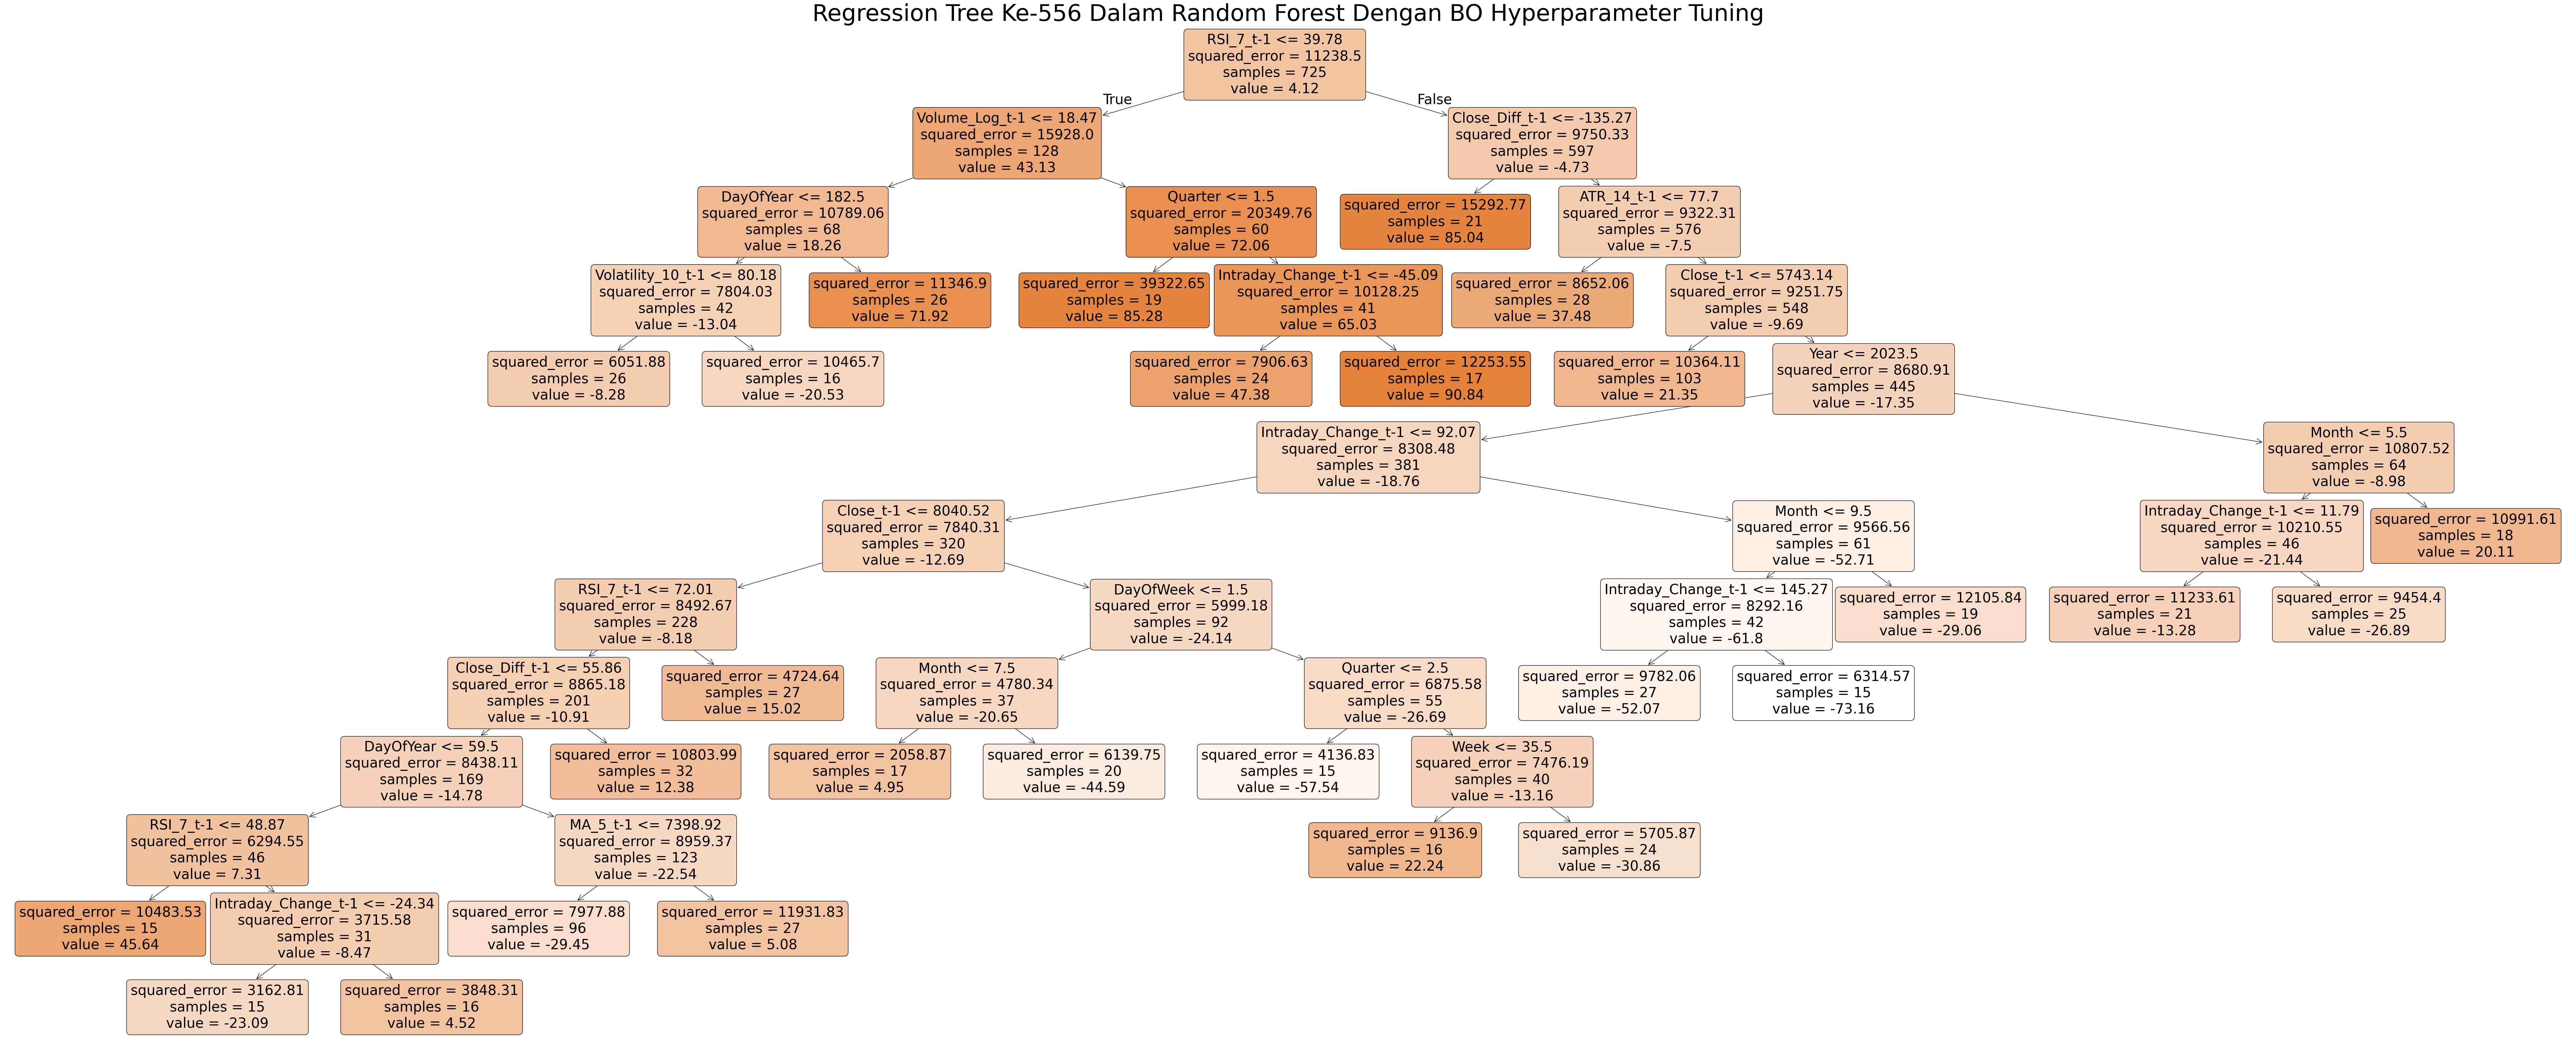

In [55]:
# Visualisasi salah satu Regression Tree yang dibangun dalam Random Forest
individual_tree = best_rf_model.estimators_[555]

plt.figure(figsize=(100, 40))
plot_tree(individual_tree,
          feature_names=X.columns.tolist(),
          filled=True,
          rounded=True,
          proportion=False,
          precision=2,
          fontsize=30)
plt.title('Regression Tree Ke-556 Dalam Random Forest Dengan BO Hyperparameter Tuning', fontsize = 50)
plt.show()


IV. MODEL EVALUATION

In [56]:
# Model Random Forest dengan Bayesian Optimization Hyperparameter Tuning melakukan prediksi terhadap variabel target 'Close_Diff'
y_pred = best_rf_model.predict(X_test)

# Melihat 1 data terbawah dari data variabel target 'Close_Diff'
y_pred = pd.DataFrame(y_pred, columns=['Pred_Close_Diff'], index=X_test.index)
y_pred.tail(1)

,Pred_Close_Diff
Date,
2025-10-02,28.744652


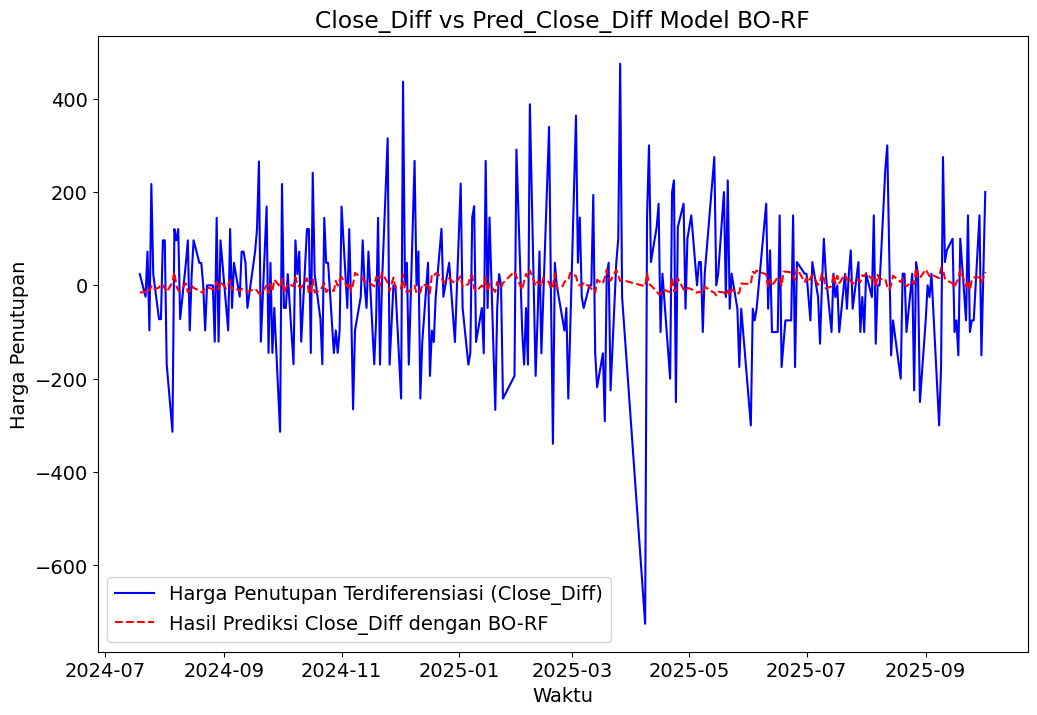

In [57]:
# Visualisasi perbandingan data 'Close_Diff' dan 'Pred_Close_Diff'
plt.figure(figsize=(12, 8))
plt.plot(y_test.index, y_test, label='Harga Penutupan Terdiferensiasi (Close_Diff)', color='blue')
plt.plot(y_test.index, y_pred, label='Hasil Prediksi Close_Diff dengan BO-RF', color='red', linestyle='--')
plt.title('Close_Diff vs Pred_Close_Diff Model BO-RF')
plt.xlabel('Waktu')
plt.ylabel('Harga Penutupan')
plt.legend()
plt.show()

In [58]:
# Mengevaluasi kinerja model BO-RF dengan metrik evaluasi
rmse = root_mean_squared_error(y_test, y_pred)
mae = mean_absolute_error(y_test, y_pred)
mape = mean_absolute_percentage_error(y_test, y_pred)
r_squared = r2_score(y_test, y_pred)

# Melihat hasil perhitungan metrik evaluasi
print('RMSE:', rmse)
print('MAE:', mae)
print('MAPE:', mape)
print('R-squared:', r_squared)

RMSE: 144.8492937304891
MAE: 111.0444643180195
MAPE: 4386396615577814.0
R-squared: 0.011804485610913518


In [59]:
# Melihat Feature Importances, tingkat kontribusi setiap variabel input dalam model BO-RF
importances = pd.Series(best_rf_model.feature_importances_, index=X.columns)

importances_sorted = importances.sort_values(ascending=False)

pd.set_option('display.max_rows', None)
pd.set_option('display.max_columns', None)

display(importances_sorted)

Close_Diff_t-1         0.096539
RSI_7_t-1              0.079017
MOM_10_t-1             0.077986
Intraday_Change_t-1    0.074956
MA_5_t-1               0.072523
Volatility_10_t-1      0.068888
Close_t-1              0.066767
ATR_14_t-1             0.066574
Volume_Log_t-1         0.066120
Intraday_Range_t-1     0.063495
DayOfYear              0.053685
DayOfMonth             0.051430
Week                   0.048989
Month                  0.033061
Year                   0.031309
DayOfWeek              0.027728
Quarter                0.017474
IsMonthEnd             0.002088
IsMonthStart           0.001369
dtype: float64

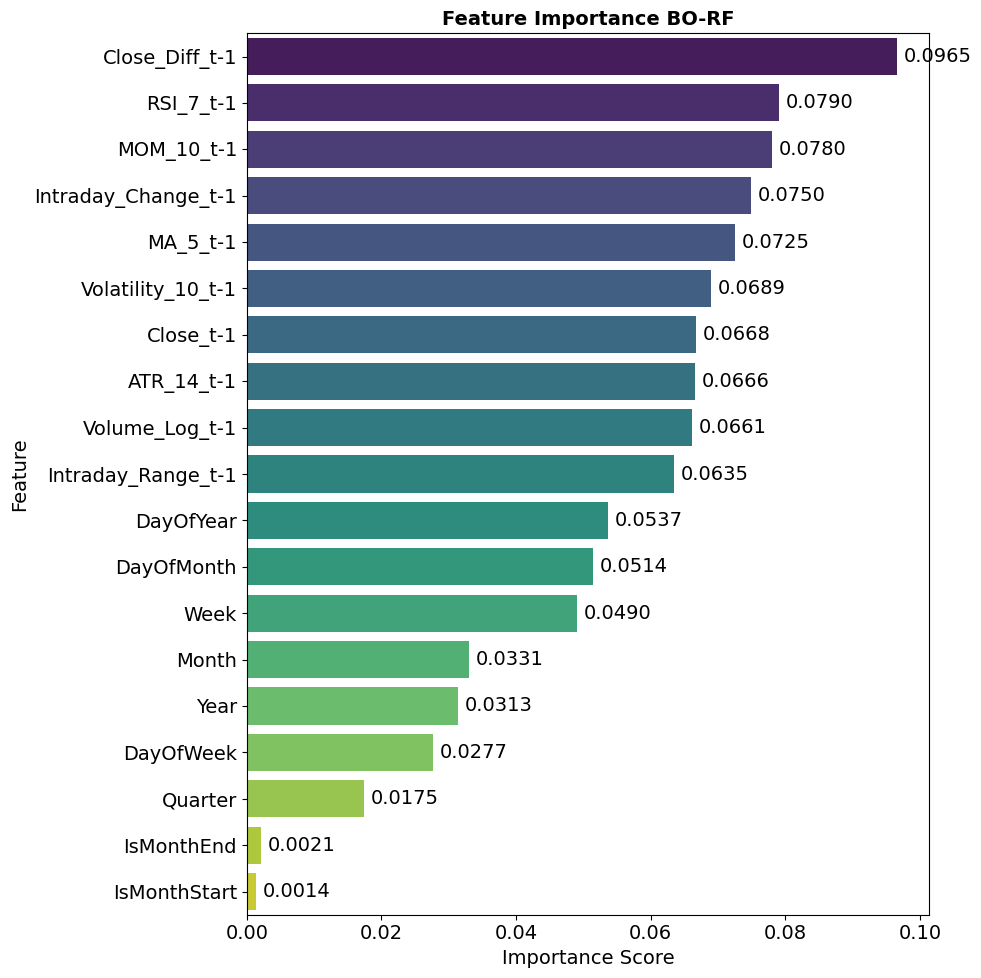

In [60]:
# Visualisasi tingkat kontribusi setiap variabel input dalam model Random Forest dengan Hyperparameter Tuning Bayesian Optimization
plt.figure(figsize=(10, 10))

ax = sns.barplot(x=importances_sorted.values,
                 y=importances_sorted.index,
                 palette="viridis")

for i, v in enumerate(importances_sorted.values):
    ax.text(v + 0.001, i, f"{v:.4f}", color='black', va='center')

plt.title("Feature Importance BO-RF", fontsize=14, weight='bold')
plt.xlabel("Importance Score")
plt.ylabel("Feature")
plt.tight_layout()
plt.show()

V. MODEL POSTPROCESSING


RMSE (Baru): 144.8492937304891
MAE (Baru): 111.04446431801946
MAPE (Baru): 0.012290632144962113
R-squared (Baru): 0.9639448501467988


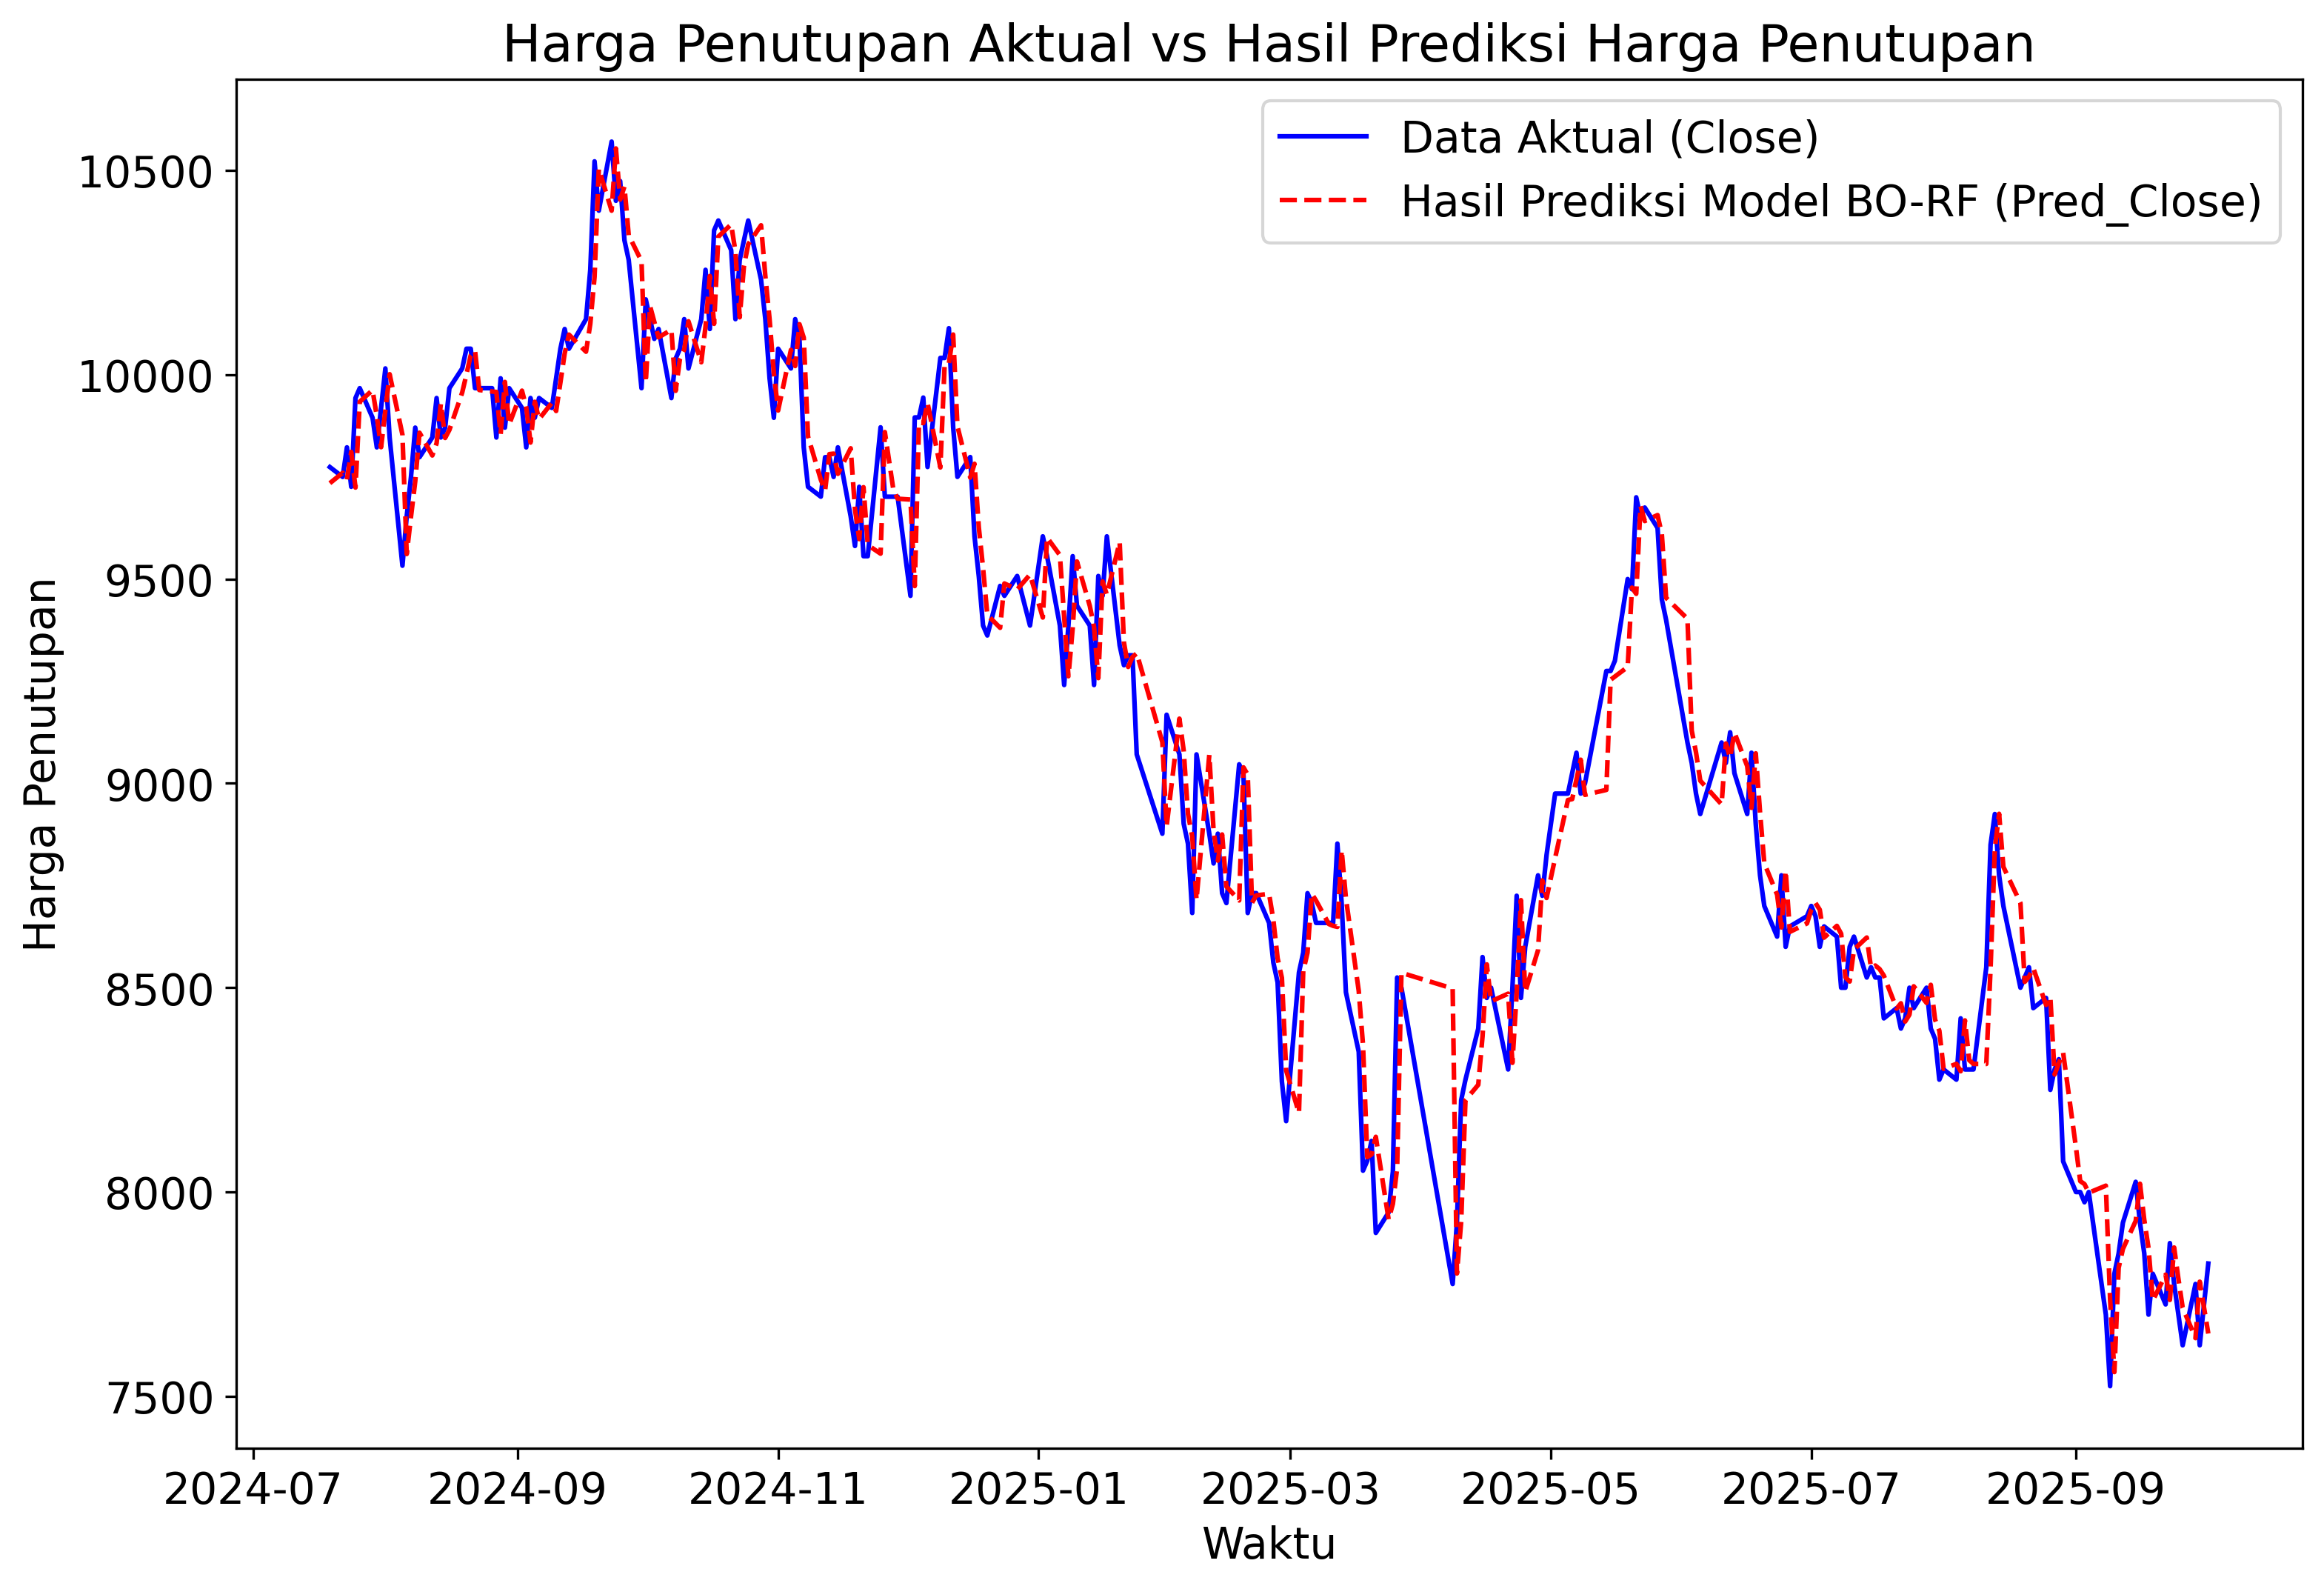

In [61]:
# Melakukan perhitungan Inversi data 'Pred_Close_Diff' menjadi 'Pred_Close'
pred_close_diff = best_rf_model.predict(X_test)
close_t_minus_1_test = df_keseluruhan.loc[X_test.index, 'Close_t-1']
close_actual_test = df_keseluruhan.loc[X_test.index, 'Close']
pred_close = close_t_minus_1_test + pred_close_diff

# Memuat variabel 'Close', 'Close_t-1', 'Pred_Close_Diff', dan 'Pred_Close' ke dalam dataset hasil_df
hasil_df = pd.DataFrame({'Close': close_actual_test,
                         'Close_t-1': close_t_minus_1_test,
                         'Pred_Close_Diff': pred_close_diff,
                         'Pred_Close': pred_close},
                        index=X_test.index)

# Evaluasi data variabel 'Pred_Close' dengan data 'Close' menggunakan metrik evaluasi
rmse_new = root_mean_squared_error(hasil_df['Close'], hasil_df['Pred_Close'])
mae_new = mean_absolute_error(hasil_df['Close'], hasil_df['Pred_Close'])
mape_new = mean_absolute_percentage_error(hasil_df['Close'], hasil_df['Pred_Close'])
r_squared_new = r2_score(hasil_df['Close'], hasil_df['Pred_Close'])

# Melihat hasil perhitungan metrik evaluasi
print('RMSE (Baru):', rmse_new)
print('MAE (Baru):', mae_new)
print('MAPE (Baru):', mape_new)
print('R-squared (Baru):', r_squared_new)

# Visualisasi perbandingan data 'Close' dan 'Pred_Close'
plt.figure(figsize=(12, 8), dpi = 300)
plt.plot(hasil_df.index, hasil_df['Close'], label='Data Aktual (Close)', color='blue')
plt.plot(hasil_df.index, hasil_df['Pred_Close'], label='Hasil Prediksi Model BO-RF (Pred_Close)', color='red', linestyle='--')
plt.title('Harga Penutupan Aktual vs Hasil Prediksi Harga Penutupan')
plt.xlabel('Waktu')
plt.ylabel('Harga Penutupan')
plt.legend()
plt.show()

In [62]:
# Menampilkan 1 data terbawah pada variabel 'Close', 'Close_t-1', 'Pred_Close_Diff', dan 'Pred_Close'
hasil_df.tail(1)

,Close,Close_t-1,Pred_Close_Diff,Pred_Close
Date,,,,
2025-10-02,7825.0,7625.0,28.744652,7653.744652
